In [1]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load dataset
df = pd.read_csv("NetFlix.csv")

In [4]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [5]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
7782,s995,TV Show,Blown Away,NaN,NaN,Canada,12-Jul-19,2019,TV-14,1,"International TV Shows, Reality TV",Ten master artists turn up the heat in glassbl...
7783,s996,TV Show,Blue Exorcist,NaN,"Nobuhiko Okamoto, Jun Fukuyama, Kana Hanazawa,...",Japan,1-Sep-20,2017,TV-MA,2,"Anime Series, International TV Shows",Determined to throw off the curse of being Sat...
7784,s997,Movie,Blue Is the Warmest Color,Abdellatif Kechiche,"Léa Seydoux, Adèle Exarchopoulos, Salim Kechio...","France, Belgium, Spain",26-Aug-16,2013,NC-17,180,"Dramas, Independent Movies, International Movies","Determined to fall in love, 15-year-old Adele ..."
7785,s998,Movie,Blue Jasmine,Woody Allen,"Cate Blanchett, Sally Hawkins, Alec Baldwin, L...",United States,8-Mar-19,2013,PG-13,98,"Comedies, Dramas, Independent Movies",The high life leads to high anxiety for a fash...
7786,s999,Movie,Blue Jay,Alex Lehmann,"Sarah Paulson, Mark Duplass, Clu Gulager",United States,6-Dec-16,2016,TV-MA,81,"Dramas, Independent Movies, Romantic Movies",Two former high school sweethearts unexpectedl...


genres
Documentaries                                                                      334
Stand-Up Comedy                                                                    321
Dramas, International Movies                                                       320
Comedies, Dramas, International Movies                                             243
Dramas, Independent Movies, International Movies                                   215
                                                                                  ... 
Kids' TV, Reality TV, Science & Nature TV                                            1
International TV Shows, Spanish-Language TV Shows, Stand-Up Comedy & Talk Shows      1
Sci-Fi & Fantasy                                                                     1
International TV Shows, TV Action & Adventure, TV Horror                             1
Stand-Up Comedy & Talk Shows, TV Mysteries, TV Sci-Fi & Fantasy                      1
Name: count, Length: 492, dtype: int

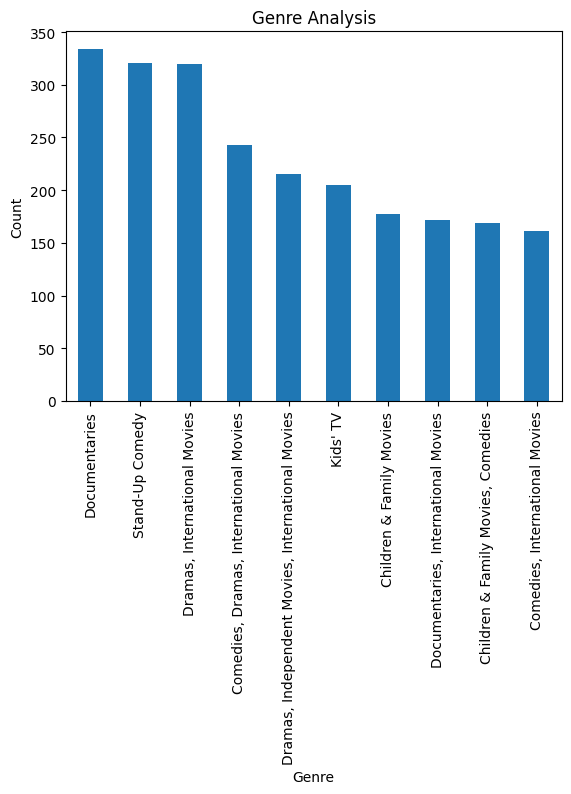

In [13]:
# Genre Count
print(df["genres"].value_counts())

# Top 10 Genres
print(df["genres"].value_counts().head(10))

# Bottom 10 Genres
print(df["genres"].value_counts().tail(10))

# Most Popular Genre
print(df["genres"].value_counts().idxmax())

# Least Popular Genre
print(df["genres"].value_counts().idxmin())

# Bar Chart
df["genres"].value_counts().head(10).plot(kind="bar")
plt.title("Genre Analysis")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

In [14]:
# Filter Movies
movies = df[df["type"] == "Movie"]

# Filter TV Shows
tvshows = df[df["type"] == "TV Show"]

# Oldest Movie
oldest_movie = movies.loc[movies["release_year"].idxmin()]
print("Oldest Movie:\n", oldest_movie)

# Newest Movie
newest_movie = movies.loc[movies["release_year"].idxmax()]
print("\nNewest Movie:\n", newest_movie)

# Oldest TV Show
oldest_tv = tvshows.loc[tvshows["release_year"].idxmin()]
print("\nOldest TV Show:\n", oldest_tv)

# Newest TV Show
newest_tv = tvshows.loc[tvshows["release_year"].idxmax()]
print("\nNewest TV Show:\n", newest_tv)

Oldest Movie:
 show_id                                                     s4961
type                                                        Movie
title                                              Prelude to War
director                                              Frank Capra
cast                                                          NaN
country                                             United States
date_added                                              31-Mar-17
release_year                                                 1942
rating                                                      TV-14
duration                                                       52
genres                              Classic Movies, Documentaries
description     Frank Capra's documentary chronicles the rise ...
Name: 4402, dtype: object

Newest Movie:
 show_id                                                     s1286
type                                                        Movie
title              

Country with Highest Netflix Content:
United States - 3297

Top 10 Countries:
country
United States     3297
India              990
United Kingdom     723
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

Bottom 10 Countries:
country
Paraguay        1
Somalia         1
Sudan           1
Panama          1
Armenia         1
Mongolia        1
Uganda          1
East Germany    1
Montenegro      1
Syria           1
Name: count, dtype: int64


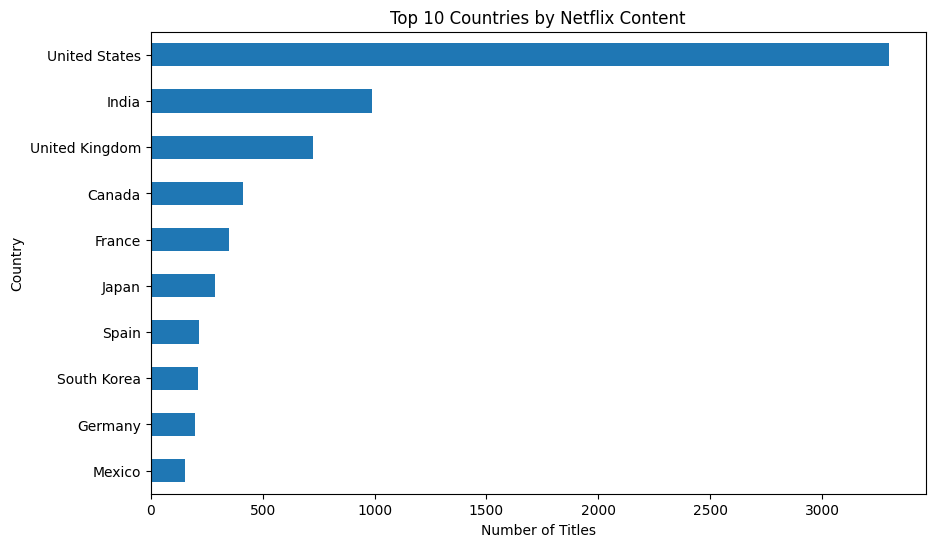

In [15]:
# Handle missing values
df = df.dropna(subset=['country'])

# Some rows have multiple countries → split them
df['country'] = df['country'].apply(lambda x: x.split(','))

# Explode into separate rows
df = df.explode('country')

# Remove extra spaces
df['country'] = df['country'].str.strip()

# Count content per country
country_counts = df['country'].value_counts()

# 1. Country with highest content
top_country = country_counts.idxmax()
top_count = country_counts.max()

print("Country with Highest Netflix Content:")
print(top_country, "-", top_count)

# 2. Top 10 Countries
top10 = country_counts.head(10)
print("\nTop 10 Countries:")
print(top10)

# 3. Bottom 10 Countries
bottom10 = country_counts.tail(10)
print("\nBottom 10 Countries:")
print(bottom10)

# 4. Horizontal Bar Chart
plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.show()

Director with Highest Movies:
Jan Suter - 21

Director with Highest TV Shows:
Alastair Fothergill - 8

Top 10 Directors:
director
Jan Suter              21
Raúl Campos            19
Martin Scorsese        18
Youssef Chahine        17
Steven Spielberg       15
Jay Karas              15
Marcus Raboy           15
Martin Campbell        14
McG                    13
Cathy Garcia-Molina    13
Name: count, dtype: int64


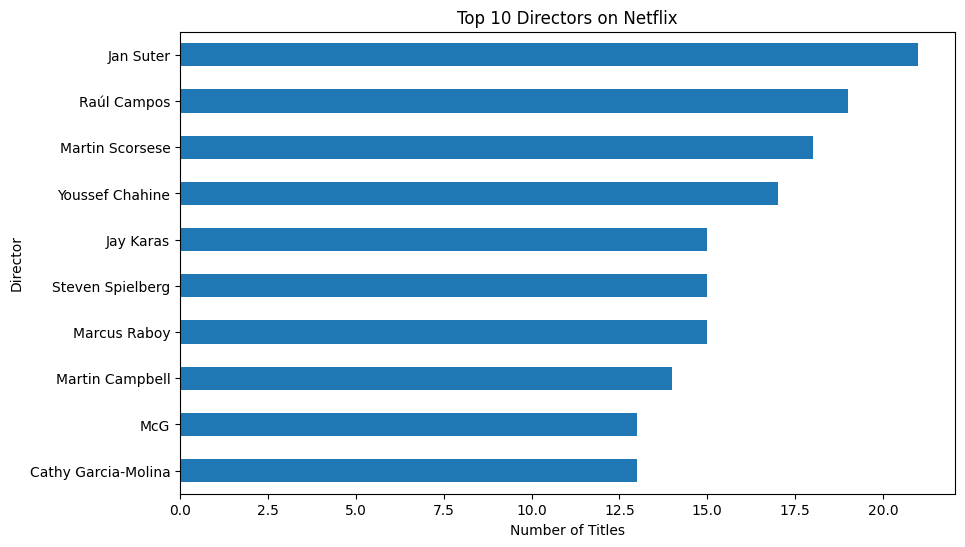

In [17]:
# Remove null directors
df = df.dropna(subset=['director'])

# Some rows have multiple directors → split
df['director'] = df['director'].apply(lambda x: x.split(','))

# Convert into separate rows
df = df.explode('director')

# Remove extra spaces
df['director'] = df['director'].str.strip()

# ----------- MOVIES -----------
movies = df[df['type'] == 'Movie']
movie_directors = movies['director'].value_counts()

top_movie_director = movie_directors.idxmax()
print("Director with Highest Movies:")
print(top_movie_director, "-", movie_directors.max())

# ----------- TV SHOWS -----------
tvshows = df[df['type'] == 'TV Show']
tv_directors = tvshows['director'].value_counts()

top_tv_director = tv_directors.idxmax()
print("\nDirector with Highest TV Shows:")
print(top_tv_director, "-", tv_directors.max())

# ----------- TOP 10 DIRECTORS -----------
top10_directors = df['director'].value_counts().head(10)
print("\nTop 10 Directors:")
print(top10_directors)

# ----------- BAR CHART -----------
plt.figure(figsize=(10,6))
top10_directors.sort_values().plot(kind='barh')
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

Before 2020: 7024
During 2020: 563
After 2020: 7


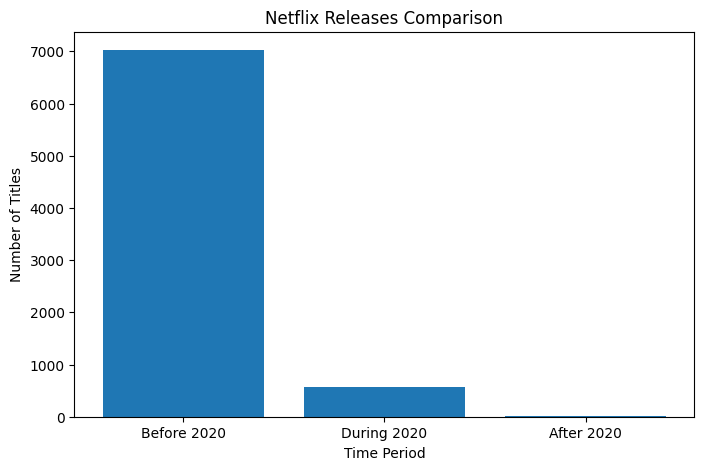

In [19]:
# Count releases based on year
before_2020 = df[df['release_year'] < 2020].shape[0]
during_2020 = df[df['release_year'] == 2020].shape[0]
after_2020 = df[df['release_year'] > 2020].shape[0]

# Store results
labels = ['Before 2020', 'During 2020', 'After 2020']
values = [before_2020, during_2020, after_2020]

# Print results
print("Before 2020:", before_2020)
print("During 2020:", during_2020)
print("After 2020:", after_2020)

# Bar Chart
plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.title("Netflix Releases Comparison")
plt.xlabel("Time Period")
plt.ylabel("Number of Titles")
plt.show()